# Photon-flux profile with detuned 493 nm coherence-time axis

This notebook produces a single output: the ion-position profile with the left axis converted from intensity to 493-nm-equivalent photon flux per unit area, and a right-hand axis showing the scattering-limited coherence time for detuned 493 nm light.


In [27]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from cycler import cycler
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
# -----------------------------
# Plot style
# -----------------------------
colors = {
    "red": "#d70000",
    "blue": "#005aa7",
    "green": "#a2ad00",
    "brown": "#6e3c1c",
}
default_cycler = cycler(color=colors )
params = {'figure.figsize': (7, 5),
          'axes.prop_cycle': default_cycler,
          'axes.titlesize': 16,
          'legend.fontsize': 12,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)
# -----------------------------
# Updated input data and approximate uncertainties
# -----------------------------
# User-supplied pairs, in A-P order: pixel position and bright probability.
point_labels = np.array(list("ABCDEFGHIJKLMNOP"))
disp_px = np.array([
    1280, 1288, 1296, 1304, 1276, 1270, 1264, 1259,
    1255, 1248, 1240, 1233, 1220, 1212, 1206, 1192,
], dtype=float)
# Retain the existing position reference and scale (2 pixels per micrometre).
disp_um = (disp_px - 1403) / 2.0+85

p_bright = np.array([
    0.0076, 0.0077, 0.014, 0.010, 0.0093, 0.011, 0.063, 0.074,
    0.061, 0.046, 0.17, 0.26, 0.08, 0.04, 0.03, 0.01,
], dtype=float)
# Approximate absolute uncertainty, comparable to the previous 0.001-0.008 range.
# This is an assumed plotting uncertainty, not a newly fitted measurement.
err_bright = np.array([0.002,0.002,0.002,0.002,0.002,0.002,0.006,0.005,0.006,0.004,0.01,0.01,0.006,0.004,0.004,0.002])
# Assumed dark baseline near 0.30; retain the prior uncertainty used at p_dark=0.30.
p_dark = np.full_like(p_bright, 0.30)
err_dark = np.full_like(p_dark, 0.010816)
frame_time_s = 0.015

# -----------------------------
# Constants and unit conversions
# -----------------------------
h = 6.62607015e-34      # J s
c = 299792458.0         # m/s
W_m2_to_mW_cm2 = 0.1    # 1 W/m^2 = 0.1 mW/cm^2
mW_cm2_to_W_m2 = 10.0   # 1 mW/cm^2 = 10 W/m^2

# Original pump-intensity inference model used for the plotted 614 nm and 455 nm points.
# These values are kept to reproduce the uploaded intensity plot before the left-axis conversion.
DETUNING_INFERENCE_HZ = 200e6
GAMMA_455_HZ = 18.8e6
GAMMA_614_HZ = 5.0e6
BRANCHING_614 = 0.215
LAMBDA_455_M = 455e-9
LAMBDA_614_M = 614e-9

# Detuned 493 nm model for the right-hand coherence-time axis.
LAMBDA_493_M = 493.4e-9
GAMMA_493_HZ = 20.1e6       # Gamma/(2*pi), total natural linewidth in Hz
DETUNING_493_HZ = 10e6      # Delta/(2*pi); coherence depends on |Delta|


E_PHOTON_493_J = h * c / LAMBDA_493_M
PHOTON_FLUX_PER_MW_CM2 = 1e-3 / E_PHOTON_493_J  # photons/(s cm^2) per mW/cm^2
PHOTON_FLUX_AXIS_SCALE = 1e14                  # plot left axis in 10^14 photons/(s cm^2)

OUTPUT_PNG = Path("detuned_493_coherence.png")


In [3]:

# -----------------------------
# Intensity and coherence models
# -----------------------------
def saturation_intensity_two_level(lambda_m: float, gamma_hz: float) -> float:
    """Return two-level saturation intensity in W/m^2, with gamma_hz = Gamma/(2*pi)."""
    gamma_rad_s = 2.0 * np.pi * gamma_hz
    return np.pi * h * c * gamma_rad_s / (3.0 * lambda_m**3)


def intensity_from_pump_rate_low_s(
    prob_transition: float,
    time_s: float,
    gamma_hz: float,
    detuning_hz: float,
    branching_factor: float,
    isat_W_m2: float,
) -> tuple[float, float]:
    """
    Low-saturation pump model:
        R_sc ≈ (Gamma/2) * s / (1 + (2 Delta/Gamma)^2)
    with gamma_hz = Gamma/(2*pi) and detuning_hz = Delta/(2*pi).

    Returns intensity in W/m^2 and s = I/Isat.
    """
    if not (0.0 < prob_transition < 1.0):
        raise ValueError("prob_transition must be between 0 and 1.")
    if time_s <= 0:
        raise ValueError("time_s must be positive.")
    if gamma_hz <= 0:
        raise ValueError("gamma_hz must be positive.")
    if not (0.0 < branching_factor <= 1.0):
        raise ValueError("branching_factor must be in (0, 1].")

    pump_rate = -np.log1p(-prob_transition) / time_s
    scattering_rate = pump_rate / branching_factor
    prefactor = np.pi * gamma_hz
    lorentz_factor = 1.0 + (2.0 * detuning_hz / gamma_hz) ** 2

    intensity_W_m2 = isat_W_m2 * (scattering_rate / prefactor) * lorentz_factor
    return intensity_W_m2, intensity_W_m2 / isat_W_m2


def intensity_and_error_from_probability(
    p: np.ndarray,
    p_err: np.ndarray,
    isat_W_m2: float,
    gamma_hz: float,
    detuning_hz: float,
    branching_factor: float,
    time_s: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Central intensity and finite-difference uncertainty from p ± sigma_p."""
    intensities = []
    errors = []
    for p_i, p_err_i in zip(p, p_err):
        I, _ = intensity_from_pump_rate_low_s(
            float(p_i), time_s, gamma_hz, detuning_hz, branching_factor, isat_W_m2
        )
        p_hi = min(float(p_i + p_err_i), 1.0 - 1e-12)
        p_lo = max(float(p_i - p_err_i), 1e-12)
        I_hi, _ = intensity_from_pump_rate_low_s(
            p_hi, time_s, gamma_hz, detuning_hz, branching_factor, isat_W_m2
        )
        I_lo, _ = intensity_from_pump_rate_low_s(
            p_lo, time_s, gamma_hz, detuning_hz, branching_factor, isat_W_m2
        )
        intensities.append(I)
        errors.append(0.5 * (I_hi - I_lo))
    return np.asarray(intensities), np.asarray(errors)


def intensity_mW_cm2_to_photon_flux_axis(intensity_mW_cm2: np.ndarray | float) -> np.ndarray:
    
    intensity = np.asarray(intensity_mW_cm2, dtype=float)
    return intensity * PHOTON_FLUX_PER_MW_CM2 / PHOTON_FLUX_AXIS_SCALE


def photon_flux_axis_to_intensity_mW_cm2(photon_flux_axis: np.ndarray | float) -> np.ndarray:
    """Inverse of intensity_mW_cm2_to_photon_flux_axis."""
    photon_flux_axis = np.asarray(photon_flux_axis, dtype=float)
    return photon_flux_axis * PHOTON_FLUX_AXIS_SCALE / PHOTON_FLUX_PER_MW_CM2


def scattering_rate_493_per_s(intensity_mW_cm2: np.ndarray | float) -> np.ndarray:

    intensity = np.asarray(intensity_mW_cm2, dtype=float)
    isat_493_mW_cm2 = saturation_intensity_two_level(LAMBDA_493_M, GAMMA_493_HZ) * W_m2_to_mW_cm2
    s = intensity / isat_493_mW_cm2
    lorentz_term = (2.0 * DETUNING_493_HZ / GAMMA_493_HZ) ** 2
    return np.pi * GAMMA_493_HZ * s / (1.0 + s + lorentz_term)


def coherence_time_493_ms(intensity_mW_cm2: np.ndarray | float) -> np.ndarray:
    """Scattering-limited coherence time tau = 1/R_sc in ms."""
    intensity = np.asarray(intensity_mW_cm2, dtype=float)
    tau_ms = np.full_like(intensity, np.nan, dtype=float)
    valid = intensity > 0
    tau_ms[valid] = 1e3 / scattering_rate_493_per_s(intensity[valid])
    return tau_ms


In [4]:

# -----------------------------
# Compute intensities, convert the left axis, and fit the 455 nm profile
# -----------------------------
isat_455 = saturation_intensity_two_level(LAMBDA_455_M, GAMMA_455_HZ)
isat_614 = saturation_intensity_two_level(LAMBDA_614_M, GAMMA_614_HZ)

I_614_W_m2, I_614_err_W_m2 = intensity_and_error_from_probability(
    p_dark,
    err_dark,
    isat_614,
    GAMMA_614_HZ,
    DETUNING_INFERENCE_HZ,
    1.0,
    frame_time_s,
)
I_455_W_m2, I_455_err_W_m2 = intensity_and_error_from_probability(
    p_bright,
    err_bright,
    isat_455,
    GAMMA_455_HZ,
    DETUNING_INFERENCE_HZ,
    BRANCHING_614,
    frame_time_s,
)

I_614_mW_cm2 = I_614_W_m2 * W_m2_to_mW_cm2
I_614_err_mW_cm2 = I_614_err_W_m2 * W_m2_to_mW_cm2
I_455_mW_cm2 = I_455_W_m2 * W_m2_to_mW_cm2
I_455_err_mW_cm2 = I_455_err_W_m2 * W_m2_to_mW_cm2

# Left-axis values: 493-nm-equivalent photon flux per unit area.
I_614_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_614_mW_cm2)
I_614_err_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_614_err_mW_cm2)
I_455_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_455_mW_cm2)
I_455_err_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_455_err_mW_cm2)
# y_fit_flux_axis = intensity_mW_cm2_to_photon_flux_axis(y_fit_mW_cm2)

# Right-axis coherence-time ticks for Delta/(2*pi) = 10 MHz.
coherence_ticks_us = np.array([100, 50, 30, 20, 15, 10, 8, 6], dtype=float)
coherence_ticks_ms = coherence_ticks_us / 1000.0

# Keep the same physical intensity range as the original plot, but in the new left-axis units.
plot_ylim = tuple(intensity_mW_cm2_to_photon_flux_axis(np.array([0.0, 0.12])))


Fit method: equal-weight least squares; zero offset; plotted error bars unchanged.
Gaussian center = -0.184 um; sigma = 4.455 um; FWHM = 10.490 um
Amplitude = 0.017647 mW/cm^2 (zero offset)
Intensity RMSE = 0.001921 mW/cm^2
Reduced chi-square diagnostic = 48.20 (13 dof; not the minimized objective)
The single Gaussian does not capture all deviations within the estimated errors.


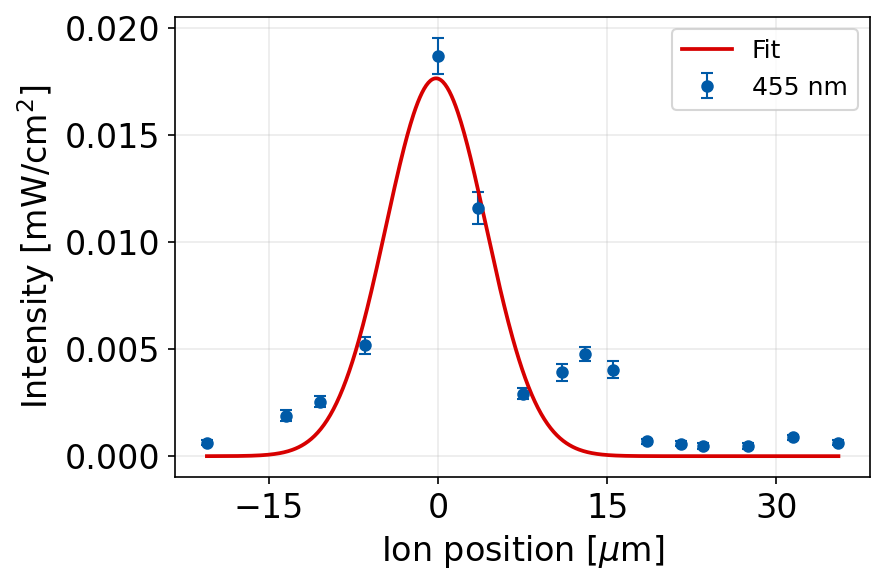

In [31]:
# -----------------------------
# Final plot: intensity data with an equal-weight Gaussian fit (no offset)
# -----------------------------
from scipy.optimize import curve_fit

# Apply the same optional position shift to both data and fit.
X_SHIFT_UM = 0
x_data_plot = disp_um
x_data_plot_shifted = x_data_plot + X_SHIFT_UM


def gaussian_profile(x, amplitude, center, sigma):
    """Intensity = amplitude * exp(-(x-center)^2 / (2*sigma^2)); zero offset."""
    return amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)


initial_guess = [
    np.max(I_455_mW_cm2)*3,
    x_data_plot_shifted[np.argmax(I_455_mW_cm2)],
    np.ptp(x_data_plot_shifted) / 8.0,
]
# Fit all intensity values with equal weight to follow the main peak.
# Error-based weighting favors the low-intensity points with smaller error bars
# and produces a broad fit below the peak. Keep the measured error bars unchanged
# for plotting and for the chi-square diagnostic; do not use them as fit weights.
# curve_fit estimates parameter covariance from the unweighted residuals.
gaussian_params, gaussian_cov = curve_fit(
    gaussian_profile,
    x_data_plot_shifted,
    I_455_mW_cm2,
    p0=initial_guess,
    bounds=(
        [0.0, np.min(x_data_plot_shifted), 1e-6],
        [np.inf, np.max(x_data_plot_shifted)+5, np.inf],
    ),
    maxfev=20000,
)
amplitude_fit, center_fit, sigma_fit = gaussian_params
fwhm_fit_um = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_fit
fit_residuals = I_455_mW_cm2 - gaussian_profile(x_data_plot_shifted, *gaussian_params)
fit_dof = len(I_455_mW_cm2) - len(gaussian_params)
fit_rmse_mW_cm2 = np.sqrt(np.mean(fit_residuals**2))
# Diagnostic only: this uncertainty-weighted quantity is not minimized by the fit.
reduced_chi2 = np.sum((fit_residuals / I_455_err_mW_cm2) ** 2) / fit_dof

print("Fit method: equal-weight least squares; zero offset; plotted error bars unchanged.")
print(f"Gaussian center = {center_fit:.3f} um; sigma = {sigma_fit:.3f} um; FWHM = {fwhm_fit_um:.3f} um")
print(f"Amplitude = {amplitude_fit:.6f} mW/cm^2 (zero offset)")
print(f"Intensity RMSE = {fit_rmse_mW_cm2:.6f} mW/cm^2")
print(f"Reduced chi-square diagnostic = {reduced_chi2:.2f} ({fit_dof} dof; not the minimized objective)")
if reduced_chi2 > 2.0:
    print("The single Gaussian does not capture all deviations within the estimated errors.")

# A monotonic grid keeps the curve smooth even though the A-P data are unsorted.
x_fit_plot_shifted = np.linspace(np.min(x_data_plot_shifted), np.max(x_data_plot_shifted), 600)
y_fit_mW_cm2 = gaussian_profile(x_fit_plot_shifted, *gaussian_params)

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.errorbar(
    x_data_plot_shifted,
    I_455_mW_cm2,
    yerr=I_455_err_mW_cm2,
    fmt="o",
    markersize=5,
    capsize=3,
    elinewidth=1,
    color=colors["blue"],
    label="455 nm",
)
ax.plot(
    x_fit_plot_shifted,
    y_fit_mW_cm2,
    color=colors["red"],
    linewidth=1.8,
    label="Fit",
)

ax.set_xlabel(r"Ion position [$\mu$m]")
ax.set_ylabel(r"Intensity [mW/cm$^2$]")
ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()

OUTPUT_PNG = "intensity_profile_dielectric_edge_25um.png"
OUTPUT_PDF = "intensity_profile_dielectric_edge_25um.pdf"
fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_PDF, bbox_inches="tight")
plt.show()


In [6]:
print(I_455_mW_cm2)

[0.00047403 0.00048029 0.00087603 0.00062447 0.00058056 0.00068727
 0.00404323 0.00477698 0.00391074 0.00292602 0.01157753 0.01870907
 0.00518089 0.00253646 0.00189257 0.00062447]
